# Problem Statement

Analyze crop production data to understand how crop type, season, state, area, rainfall, fertilizer, pesticide usage, and other factors are associated with crop yield.

In [19]:
# import libary
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv(r"C:\Users\Piyush\Downloads\unclean_crop_yield.csv")
df.head()

,Crop,Crop Year,Season,STATE,Area,Production,Annual Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708.0,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685.0,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22.0,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000.0,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794.0,2051.4,165500.63,539.09,0.420909


In [21]:
df.tail()

,Crop,Crop Year,Season,STATE,Area,Production,Annual Rainfall,Fertilizer,Pesticide,Yield
19934,Potato,2002,Whole Year,Jammu and Kashmir,1737.0,18011.0,933.2000,164441.79,434.25,9.146667
19935,rice,2006,NaN,Puducherry,12061.0,NaN,1434.5875,1540310.31,2653.42,4.050000
19936,Peas & beans (Pulses),1999,Rabi,West Bengal,7041.0,6027.0,2318.1000,747261.33,1901.07,0.931333
19937,Arecanut,2004,Whole Year,Karnataka,152759.0,203646.0,1117.7000,16549910.06,32079.39,1.297273
19938,Soyabean,1999,Kharif,Nagaland,12500.0,14000.0,1782.2000,1326625.00,3375.00,1.121429


In [22]:
df.shape

(19939, 10)

In [23]:
df.columns

Index([' Crop ', 'Crop Year', 'Season ', ' STATE', 'Area', 'Production',
       'Annual Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='str')

In [24]:
# Clean Columns Names
df.columns= (df.columns.str.strip().str.title().str.replace(' ','_'))

In [25]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='str')

In [26]:
# Understanding Data Types
df.dtypes

Crop                   str
Crop_Year            int64
Season                 str
State                  str
Area               float64
Production         float64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19939 entries, 0 to 19938
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19467 non-null  str    
 1   Crop_Year        19939 non-null  int64  
 2   Season           19640 non-null  str    
 3   State            19778 non-null  str    
 4   Area             19582 non-null  float64
 5   Production       19496 non-null  float64
 6   Annual_Rainfall  19441 non-null  float64
 7   Fertilizer       19582 non-null  float64
 8   Pesticide        19603 non-null  float64
 9   Yield            19537 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 2.1 MB


In [28]:
df.select_dtypes(include='number')

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,1997,73814.0,56708.0,2051.4000,7024878.38,22882.34,0.796087
1,1997,6637.0,4685.0,2051.4000,631643.29,2057.47,0.710435
2,1997,796.0,22.0,2051.4000,75755.32,246.76,0.238333
3,1997,19656.0,126905000.0,2051.4000,1870661.52,6093.36,5238.051739
4,1997,1739.0,794.0,2051.4000,165500.63,539.09,0.420909
...,...,...,...,...,...,...,...
19934,2002,1737.0,18011.0,933.2000,164441.79,434.25,9.146667
19935,2006,12061.0,NaN,1434.5875,1540310.31,2653.42,4.050000
19936,1999,7041.0,6027.0,2318.1000,747261.33,1901.07,0.931333
19937,2004,152759.0,203646.0,1117.7000,16549910.06,32079.39,1.297273


In [29]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19939.000000,1.958200e+04,1.949600e+04,19441.000000,1.958200e+04,1.960300e+04,19537.000000
mean,2009.136015,2.018602e+05,3.815946e+07,1459.122446,2.845639e+07,6.021984e+04,81.251204
std,6.495155,1.335159e+06,3.105984e+09,1023.389966,2.994460e+08,7.728019e+05,885.562914
min,1997.000000,-1.906300e+06,-6.926960e+05,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.387000e+03,1.388500e+03,939.200000,1.901561e+05,3.592250e+02,0.598095
50%,2010.000000,9.303500e+03,1.380450e+04,1247.600000,1.242932e+06,2.417850e+03,1.030000
75%,2015.000000,7.537800e+04,1.237002e+05,1648.200000,1.014898e+07,2.013673e+04,2.395556
max,2020.000000,1.194621e+08,4.321762e+11,45192.800000,2.473638e+10,6.913335e+07,21105.000000


In [30]:
df.select_dtypes(exclude='number')

,Crop,Season,State
0,Arecanut,Whole Year,Assam
1,Arhar/Tur,Kharif,Assam
2,Castor seed,Kharif,Assam
3,Coconut,Whole Year,Assam
4,Cotton(lint),Kharif,Assam
...,...,...,...
19934,Potato,Whole Year,Jammu and Kashmir
19935,rice,NaN,Puducherry
19936,Peas & beans (Pulses),Rabi,West Bengal
19937,Arecanut,Whole Year,Karnataka


# Check Unique Values

In [127]:

df['Crop'].unique()

<ArrowStringArray>
[             'Arecanut',             'Arhar/Tur',           'Castor Seed',
               'Coconut',          'Cotton(Lint)',          'Dry Chillies',
                  'Gram',                  'Jute',               'Linseed',
                 'Maize',                 'Mesta',            'Niger Seed',
                 'Onion',     'Other Rabi Pulses',                'Potato',
     'Rapeseed &Mustard',                  'Rice',               'Sesamum',
         'Small Millets',             'Sugarcane',          'Sweet Potato',
               'Tapioca',               'Tobacco',              'Turmeric',
                 'Wheat',                 'Bajra',          'Black Pepper',
              'Cardamom',             'Coriander',                'Garlic',
                'Ginger',             'Groundnut',            'Horse-Gram',
                 'Jowar',                  'Ragi',             'Cashewnut',
                'Banana',              'Soyabean',                'Ba

In [48]:
df['Crop'].isnull().sum()

np.int64(472)

In [38]:
df['Crop']=(df.Crop.str.T().str.strip())
df['Crop']

0                     Arecanut
1                    Arhar/Tur
2                  Castor Seed
3                      Coconut
4                 Cotton(Lint)
                 ...          
19934                   Potato
19935                     Rice
19936    Peas & Beans (Pulses)
19937                 Arecanut
19938                 Soyabean
Name: Crop, Length: 19939, dtype: str

In [39]:
df['Crop'].nunique()

55

In [41]:
df['State']=(df.State.str.title().str.strip())
df['State']

0                    Assam
1                    Assam
2                    Assam
3                    Assam
4                    Assam
               ...        
19934    Jammu And Kashmir
19935           Puducherry
19936          West Bengal
19937            Karnataka
19938             Nagaland
Name: State, Length: 19939, dtype: str

In [49]:
df['State'].nunique()

30

In [51]:
df['Season'].unique()

<ArrowStringArray>
[  'Whole Year ',   'Kharif     ',   'Rabi       ',   'Autumn     ',
   'Summer     ',   'Winter     ',             nan,   'whole year ',
   'rabi       ', ' Whole Year  ', ' Kharif      ',   'kharif     ',
 ' Rabi        ', ' Autumn      ', ' Summer      ', ' Winter      ',
 ' kharif      ',   'summer     ',   'autumn     ',   'winter     ']
Length: 20, dtype: str

In [52]:
df['Season']

0        Whole Year 
1        Kharif     
2        Kharif     
3        Whole Year 
4        Kharif     
            ...     
19934    Whole Year 
19935            NaN
19936    Rabi       
19937    Whole Year 
19938    Kharif     
Name: Season, Length: 19939, dtype: str

In [53]:
df['Season'].nunique()

19

In [57]:
# Clean Text Columns
categorical_columns =['Crop','Season','State']
for col in categorical_columns:
    df[col]=(df[col].astype('string').str.strip().str.replace(r'\s+',' ',regex=True).str.title())

In [58]:
df['Season'].unique()

<ArrowStringArray>
['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter', <NA>]
Length: 7, dtype: string

In [59]:
df.isnull().sum()

Crop               472
Crop_Year            0
Season             299
State              161
Area               357
Production         443
Annual_Rainfall    498
Fertilizer         357
Pesticide          336
Yield              402
dtype: int64

# Check Percentage

In [144]:

missing_percentage = df.isnull().mean() * 100
missing_percentage.sort_values(ascending=False)

Yield              2.005178
log_yield          2.005178
Crop               0.000000
Season             0.000000
Crop_Year          0.000000
State              0.000000
Area               0.000000
Annual_Rainfall    0.000000
Production         0.000000
Pesticide          0.000000
Fertilizer         0.000000
dtype: float64

# Visualize Missing Values

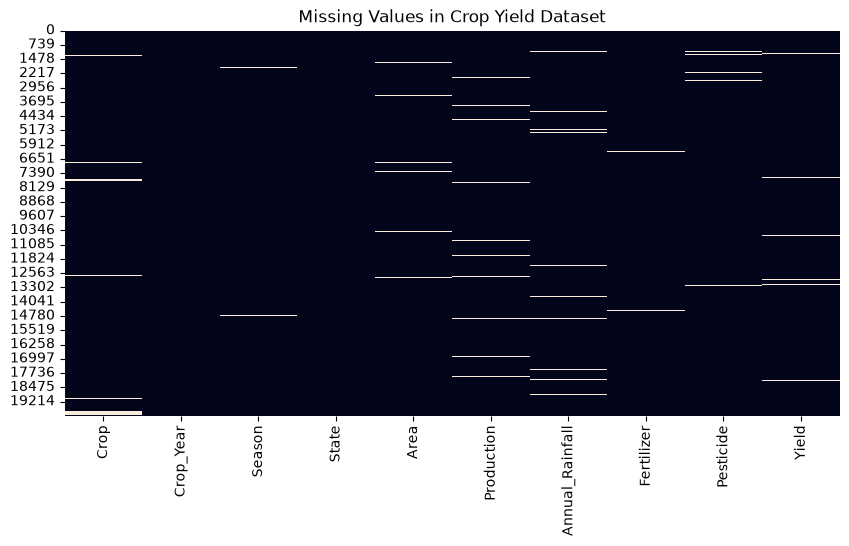

In [61]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Crop Yield Dataset")
plt.show()

# Obervation :

The heatmap shows that missing values are distributed across several columns. Annual Rainfall has one of the larger numbers of missing observations, while Crop Year has no missing values.

# Handling Missing Values

In [62]:
for col in ['Crop','Season','State']:
    df[col]= df[col].fillna(df[col].mode()[0])

In [63]:
numeric_columns =['Area','Production','Annual_Rainfall','Fertilizer','Pesticide']
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [64]:
df_eda = df.dropna(subset=['Yield']).copy()

In [80]:
df.isnull().sum()

Crop                 0
Crop_Year            0
Season               0
State                0
Area                 0
Production           0
Annual_Rainfall      0
Fertilizer           0
Pesticide            0
Yield              395
log_yield          395
dtype: int64

# Check Duplicate Records

In [65]:
df.duplicated().sum()

np.int64(240)

In [66]:
df = df.drop_duplicates()

In [67]:
df.duplicated().sum()

np.int64(0)

# Check Outliers 

In [68]:
numeric_columns =['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']

# Boxplots

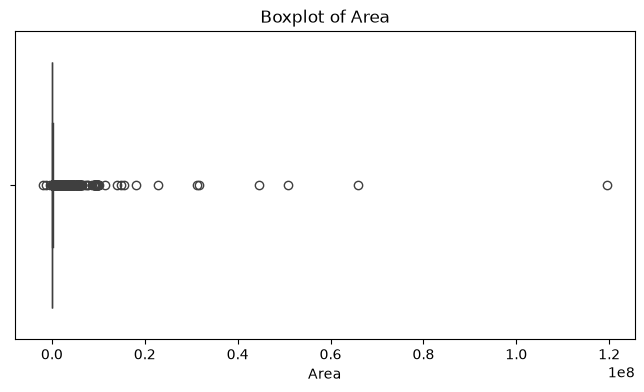

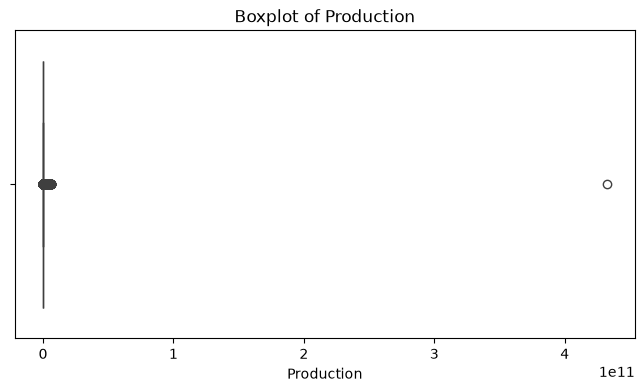

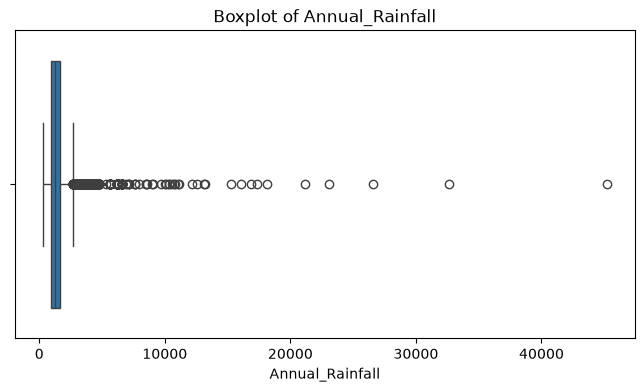

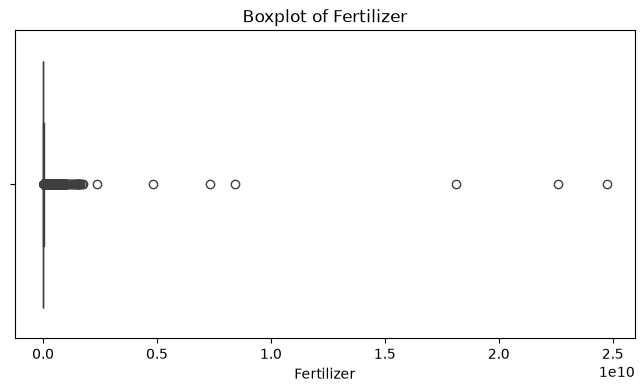

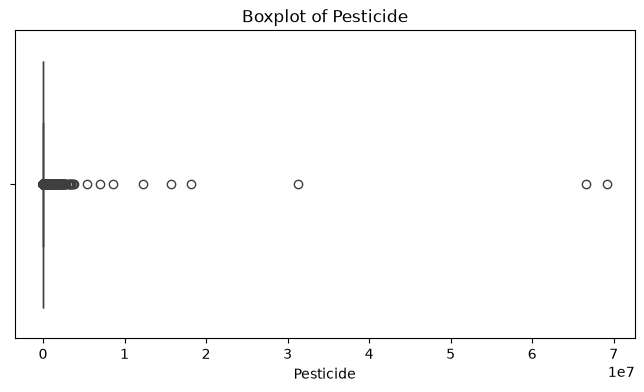

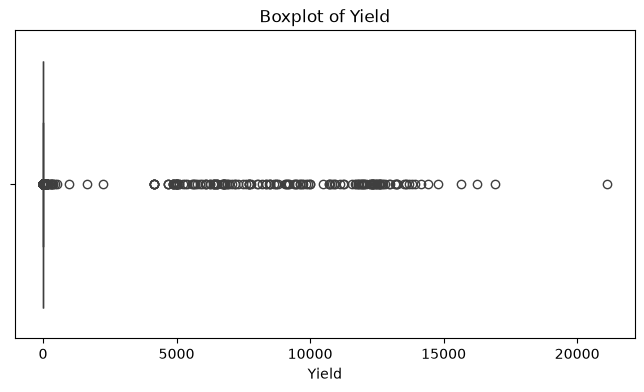

In [69]:
for col in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# IQR Method
- IQR = Q3-Q1
- lb = Q1 - 1.5 *IQR
- ub = Q3 + 1.5 * IQR

In [75]:
def detect_outliers(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3- Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = data [
        (data[column] < lower) | 
        (data[column] > upper)
    ]
    return outlier


In [76]:
outliers_yield = detect_outliers(df, 'Yield')

len(outliers_yield)

3033

In [77]:
df['log_yield'] = np.log1p(df['Yield'])

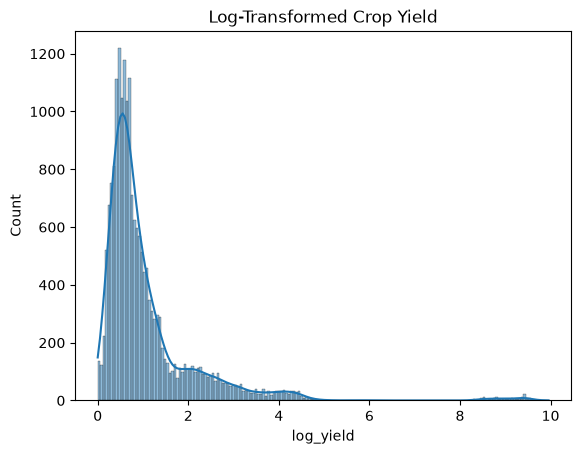

In [78]:
sns.histplot(df['log_yield'],kde= True)
plt.title ("Log-Transformed Crop Yield")
plt.show()

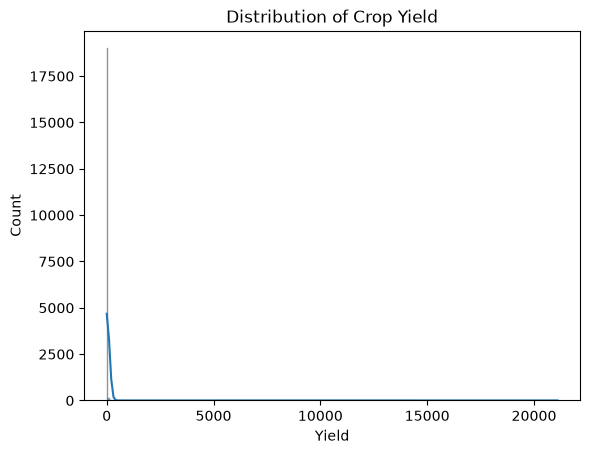

In [79]:
sns.histplot(df['Yield'], kde=True)
plt.title("Distribution of Crop Yield")
plt.show()

In [81]:
df.isnull().sum()

Crop                 0
Crop_Year            0
Season               0
State                0
Area                 0
Production           0
Annual_Rainfall      0
Fertilizer           0
Pesticide            0
Yield              395
log_yield          395
dtype: int64

# Now Start EDA 
1) Univariate analysis
2) Bivariate analysis
3) Multivariate analysis
4) Appropriate visualizations.

# Univariate analysis
Analysis of one variable at a time.

# univariate analysis - crop

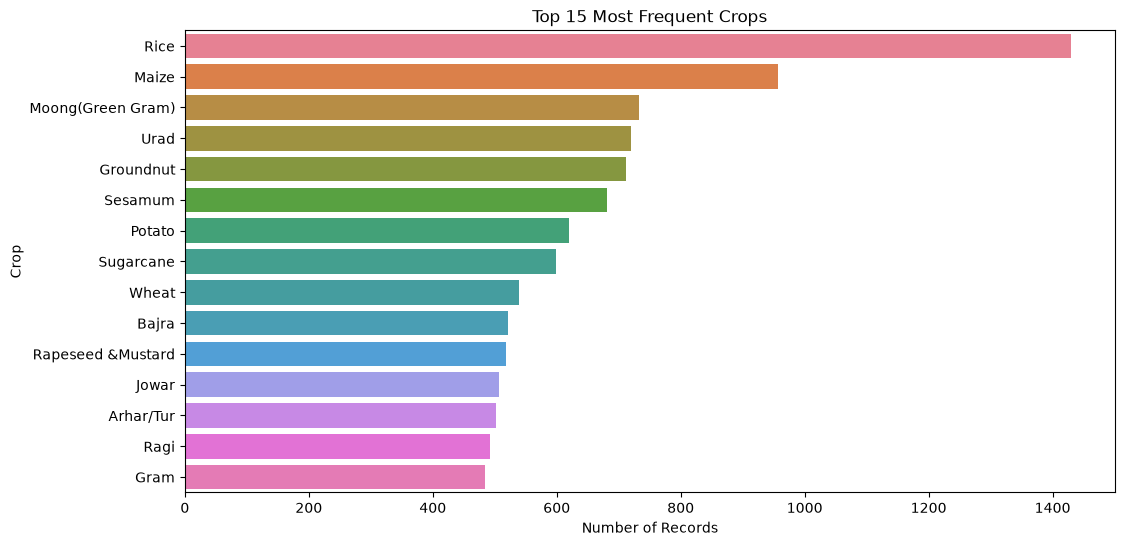

In [87]:
crop_counts = df['Crop'].value_counts().head(15)
plt.figure(figsize =(12,6))
sns.barplot(x=crop_counts.values,y=crop_counts.index,hue=crop_counts.index, palette='husl',legend = False)
plt.title("Top 15 Most Frequent Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

# univariate analysis - Season

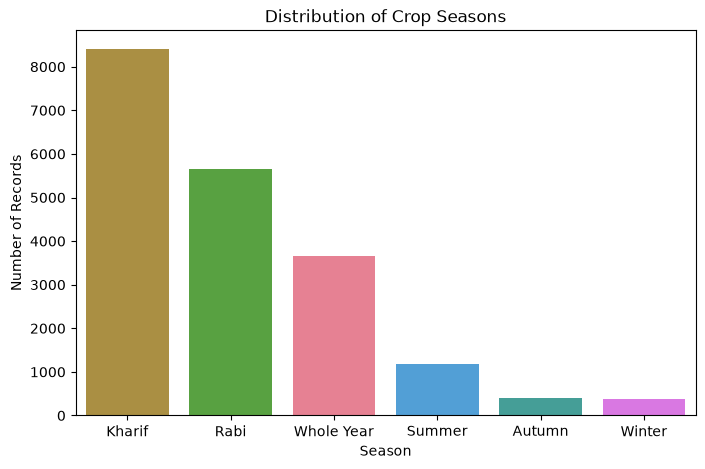

In [85]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Season',order=df['Season'].value_counts().index,hue='Season', palette='husl',legend = False)
plt.title("Distribution of Crop Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.xticks(rotation=360)

plt.show()

# Univariate Analysis - State

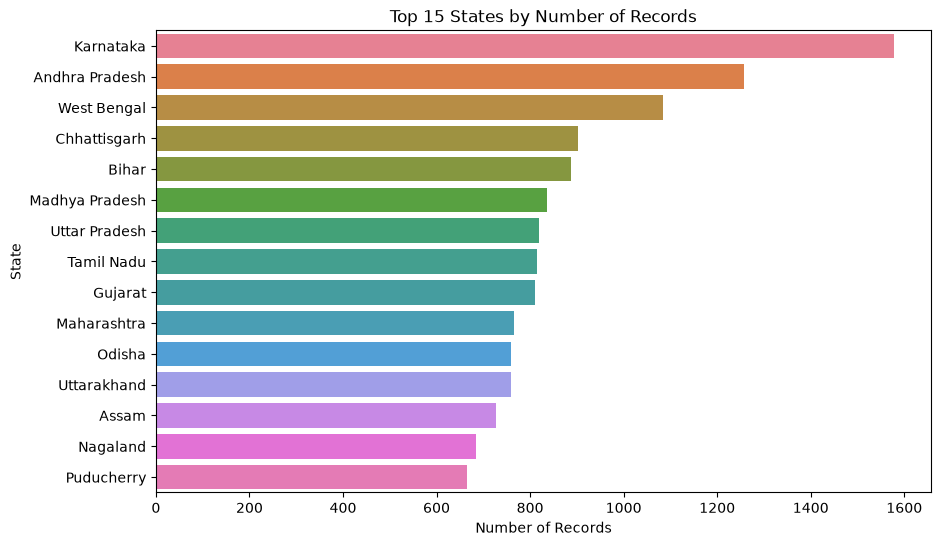

In [88]:
state_counts = df['State'].value_counts().head(15)

plt.figure(figsize=(10,6))

sns.barplot(x=state_counts.values,y=state_counts.index,hue=state_counts.index, palette='husl',legend = False)

plt.title("Top 15 States by Number of Records")

plt.xlabel("Number of Records")
plt.ylabel("State")
plt.show()

# Univariate Analysis — Crop Year

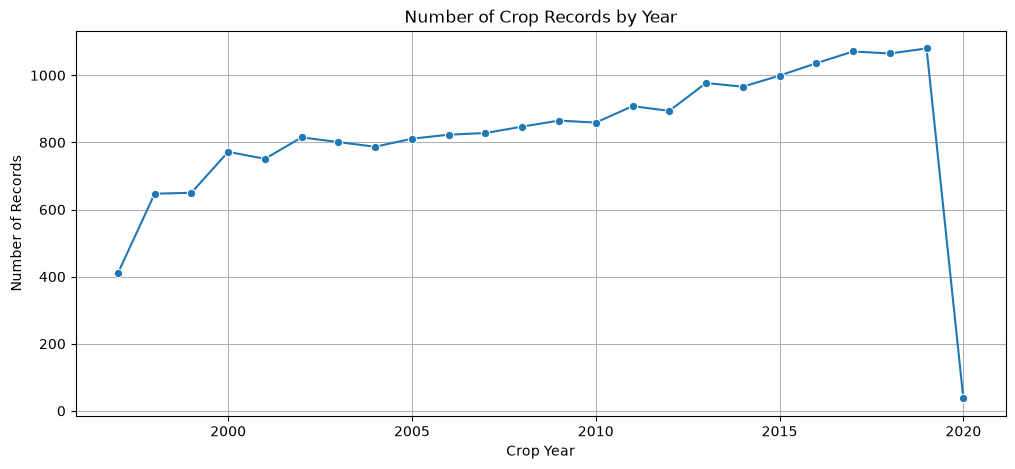

In [91]:
year_counts = df['Crop_Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_counts.values
sns.lineplot(x=year_counts.index,y=year_counts.values,marker='o')

plt.title("Number of Crop Records by Year")
plt.grid()
plt.xlabel("Crop Year")
plt.ylabel("Number of Records")

plt.show()

Normal

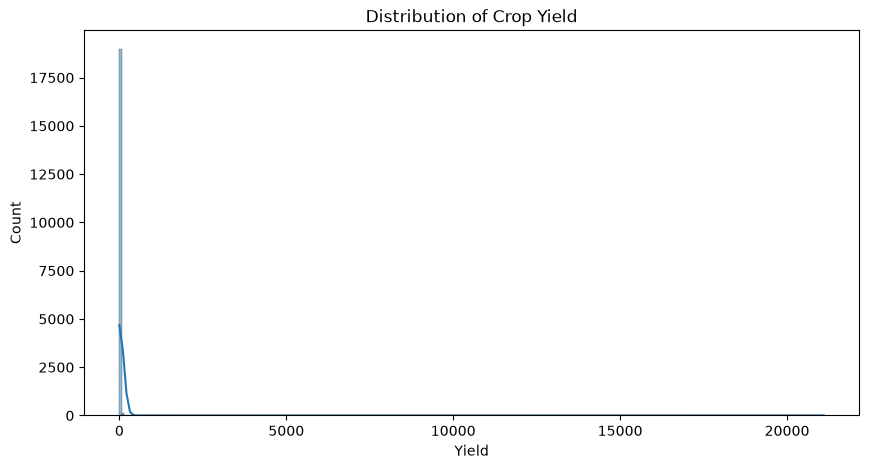

In [92]:

plt.figure(figsize=(10,5))

sns.histplot(df['Yield'], kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")

plt.show()

log

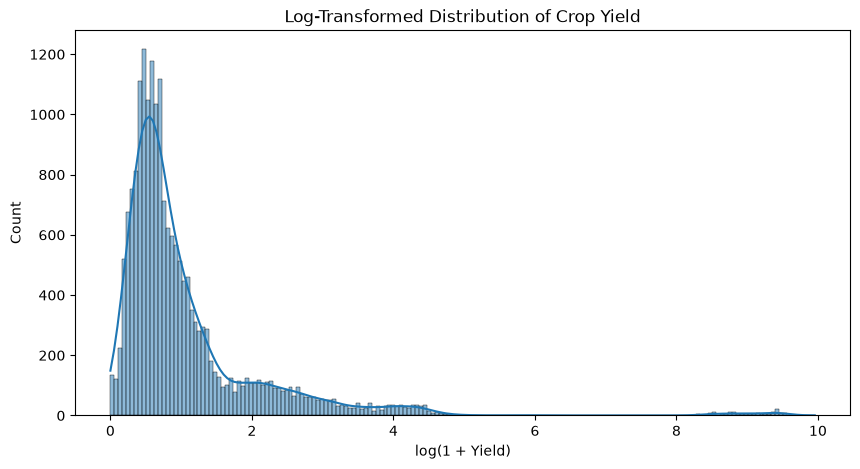

In [93]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['Yield']), kde=True)

plt.title("Log-Transformed Distribution of Crop Yield")
plt.xlabel("log(1 + Yield)")

plt.show()

# Univariate Boxplot — Yield

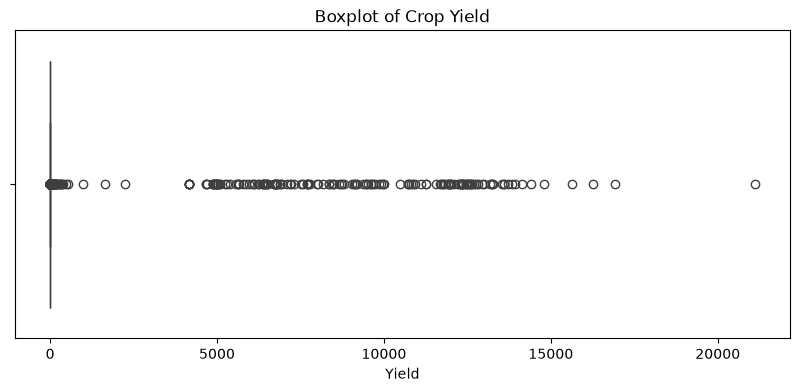

In [94]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['Yield'])

plt.title("Boxplot of Crop Yield")
plt.xlabel("Yield")

plt.show()

# Bivariate Analysis
Studying the relationship between two variables.

# Yield vs Area

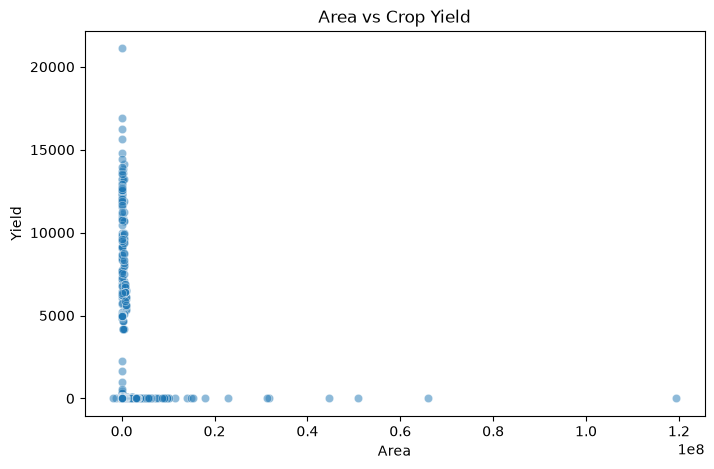

In [95]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='Area',y='Yield',alpha=0.5)
plt.title("Area vs Crop Yield")
plt.xlabel("Area")
plt.ylabel("Yield")
plt.show()

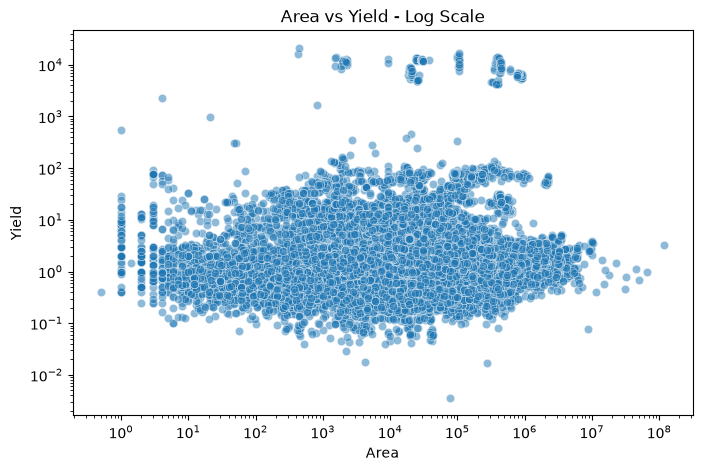

In [96]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='Area',y='Yield',alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.title("Area vs Yield - Log Scale")

plt.show()

# Production vs Yield

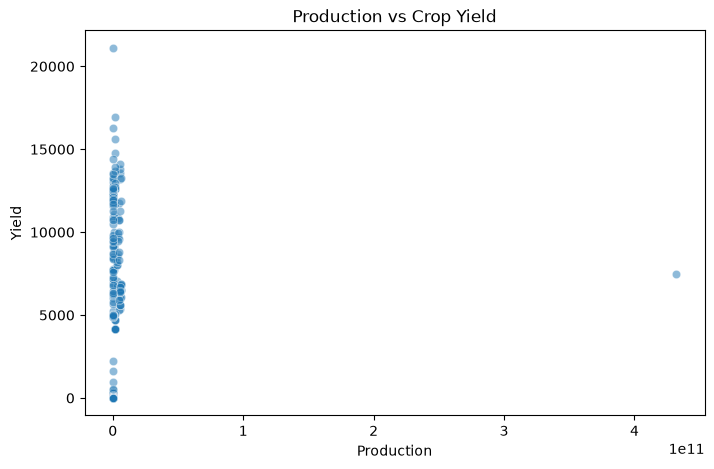

In [97]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='Production',y='Yield',alpha=0.5)

plt.title("Production vs Crop Yield")

plt.show()

# Rainfall vs Yield 

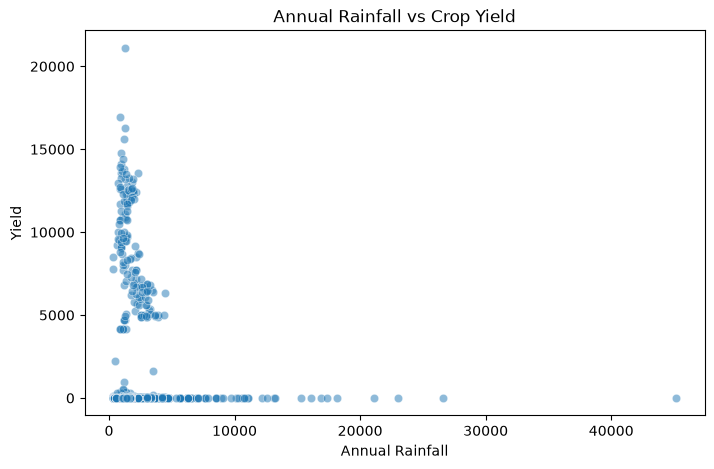

In [98]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Annual_Rainfall',
    y='Yield',
    alpha=0.5
)

plt.title("Annual Rainfall vs Crop Yield")

plt.xlabel("Annual Rainfall")
plt.ylabel("Yield")

plt.show()

# Fertilizer vs Yield

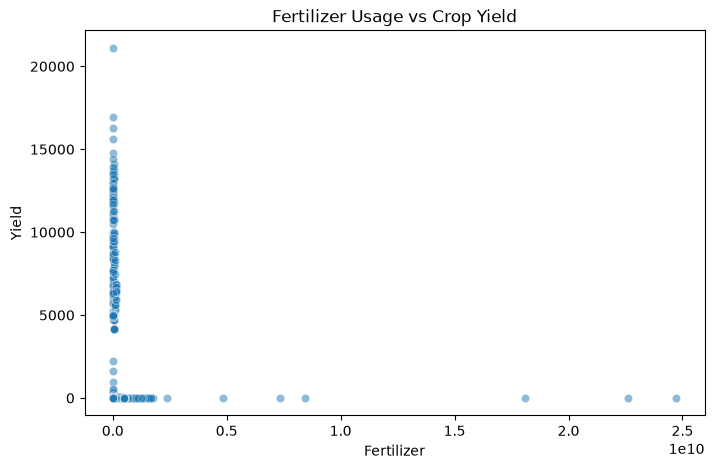

In [99]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='Fertilizer',y='Yield',alpha=0.5)

plt.title("Fertilizer Usage vs Crop Yield")

plt.show()

# Pesticide vs Yield

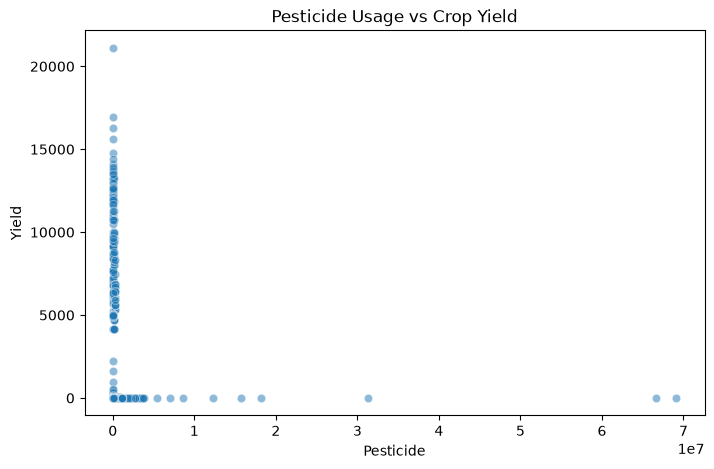

In [101]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='Pesticide',y='Yield',alpha=0.5)

plt.title("Pesticide Usage vs Crop Yield")

plt.show()

# Season vs Yield

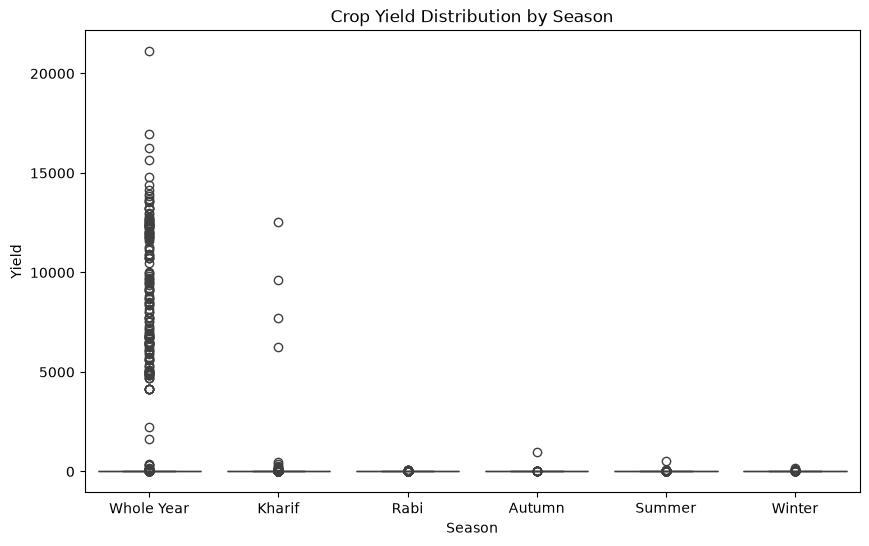

In [102]:
plt.figure(figsize=(10,6))

sns.boxplot( data=df,x='Season',y='Yield')

plt.title("Crop Yield Distribution by Season")



plt.show()

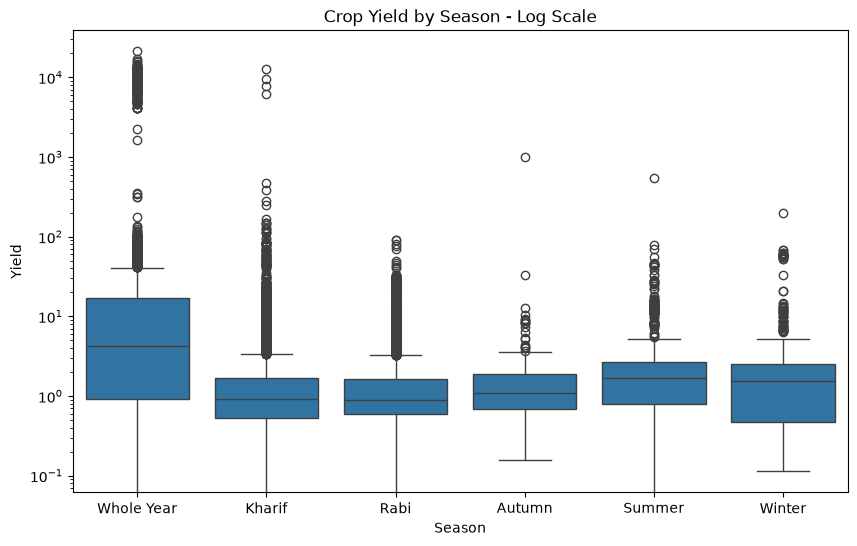

In [103]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df,x='Season',y='Yield')

plt.yscale('log')

plt.title("Crop Yield by Season - Log Scale")



plt.show()

# Top Crops vs Yield

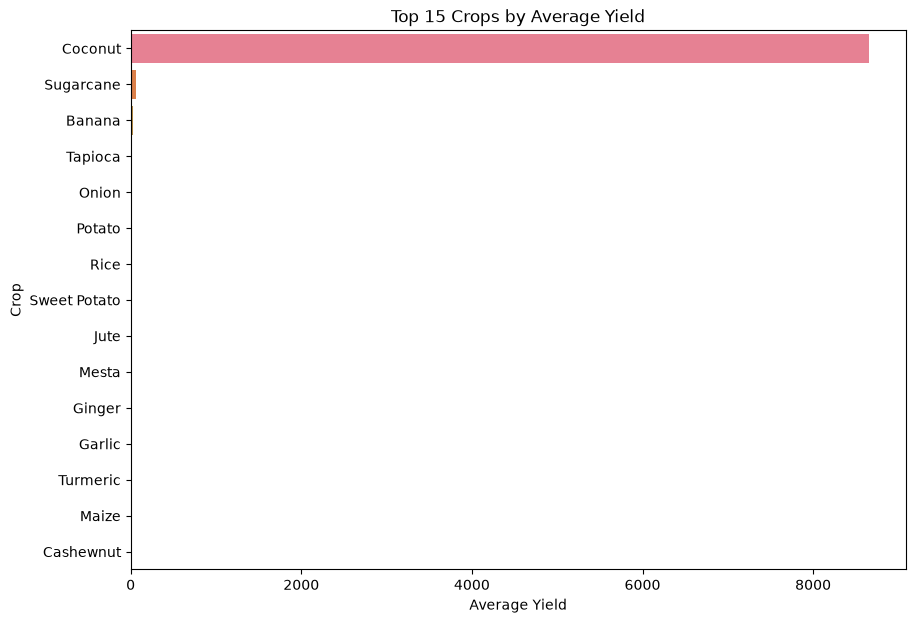

In [125]:
top_crops = (
    df.groupby('Crop')['Yield']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10,7))

sns.barplot(x=top_crops.values,y=top_crops.index,hue=top_crops.index,palette='husl')

plt.title("Top 15 Crops by Average Yield")

plt.xlabel("Average Yield")
plt.ylabel("Crop")

plt.show()

# State vs Average Yield

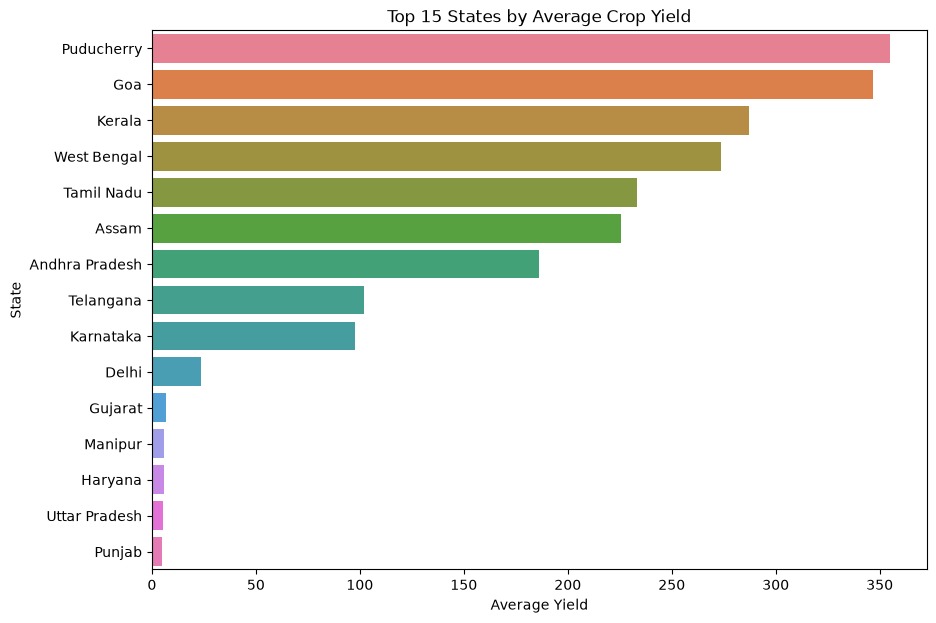

In [126]:
state_yield = (
    df.groupby('State')['Yield']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10,7))

sns.barplot(x=state_yield.values,y=state_yield.index,palette='husl',hue=state_yield.index)

plt.title("Top 15 States by Average Crop Yield")

plt.xlabel("Average Yield")
plt.ylabel("State")

plt.show()

# Multivariate Analysis
Studying more than two variables simultaneously.

# Correlation Matrix

In [115]:
numeric_cols = ['Crop_Year','Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']

correlation = df[numeric_cols].corr()

# Heatmap

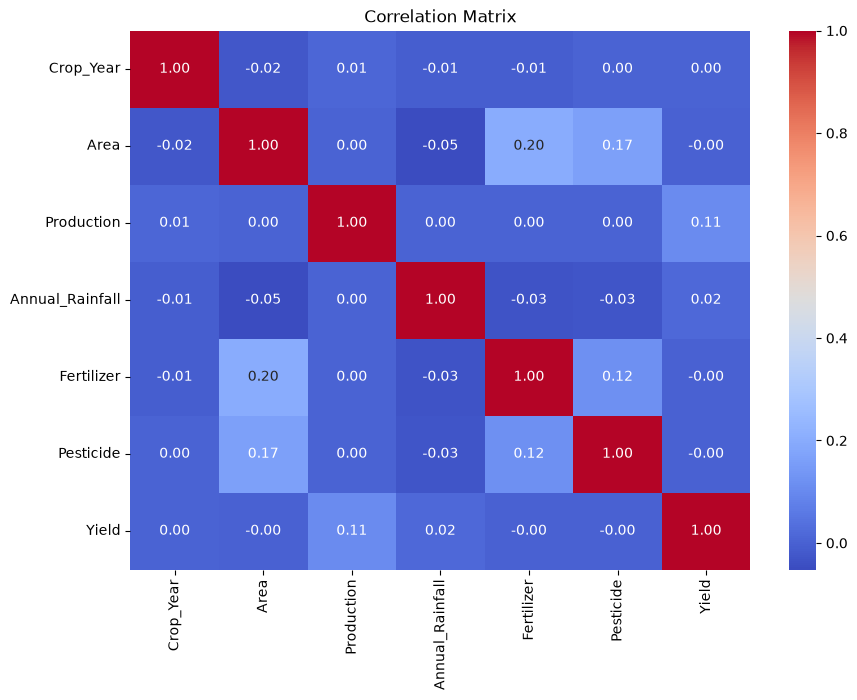

In [116]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# Find Correlation with Yield 

In [118]:
correlation['Yield'].sort_values(ascending=False)

Yield              1.000000
Production         0.106540
Annual_Rainfall    0.015416
Crop_Year          0.002504
Area              -0.000261
Fertilizer        -0.000457
Pesticide         -0.000717
Name: Yield, dtype: float64

# Crop + Season + Yield

In [131]:
state_season = pd.pivot_table(df, values='Yield', index='Crop', columns='Season', aggfunc='mean').fillna(0)
state_season.head()

Season,Autumn,Kharif,Rabi,Summer,Whole Year,Winter
Crop,,,,,,
Arecanut,0.000000,4.477824,1.066196,0.000000,2.180200,0.000000
Arhar/Tur,0.202778,0.810747,1.355939,0.216786,1.098249,23.186976
Bajra,0.000000,1.125507,1.274560,1.858473,26.336507,0.000000
Banana,12.720000,23.012204,12.894000,40.003218,26.610596,12.878333
Barley,0.000000,1.519609,1.601585,0.000000,1.633026,0.000000


# Heatmap

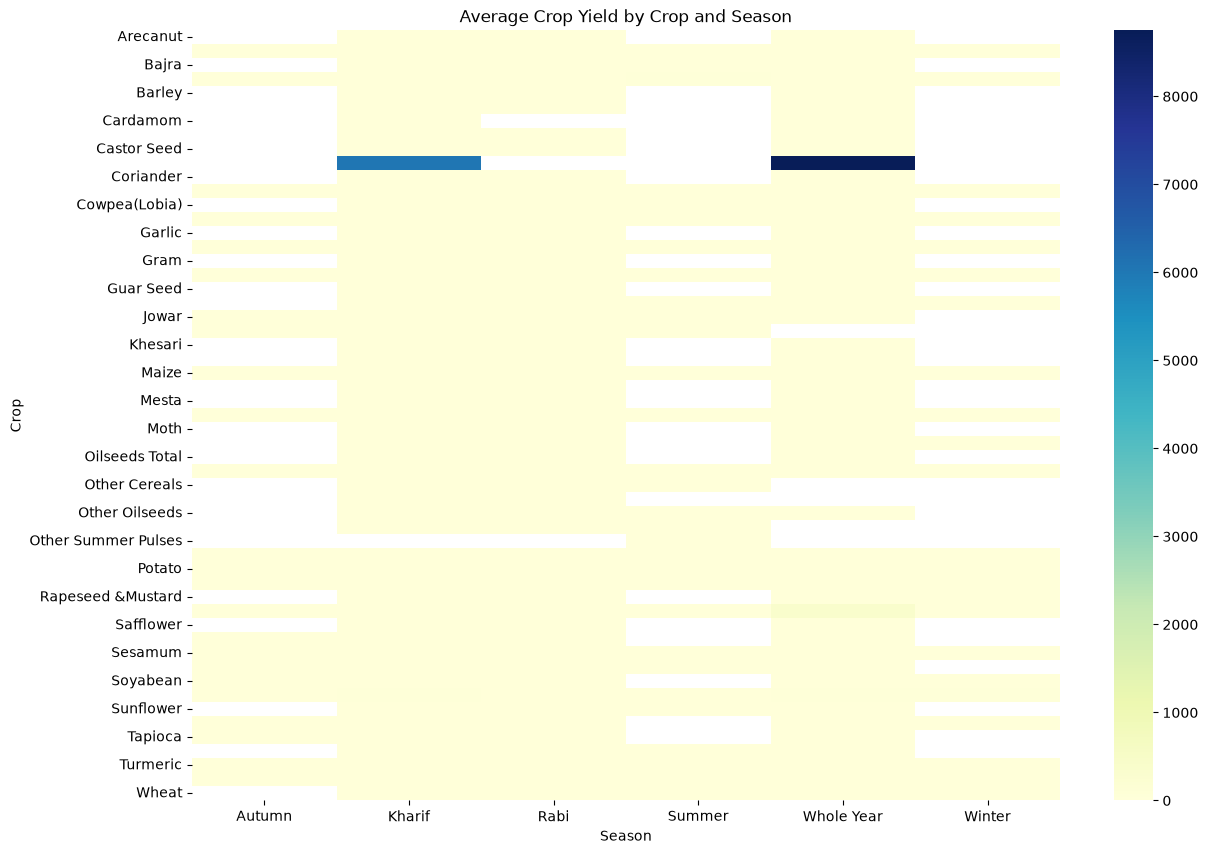

In [146]:
plt.figure(figsize=(14,10))

sns.heatmap( pivot,cmap='YlGnBu')

plt.title("Average Crop Yield by Crop and Season")

plt.show()

This is an excellent multivariate visualization.

# Pairplot

In [138]:
sample_df = df[
    ['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']
].sample(2000, random_state=42)

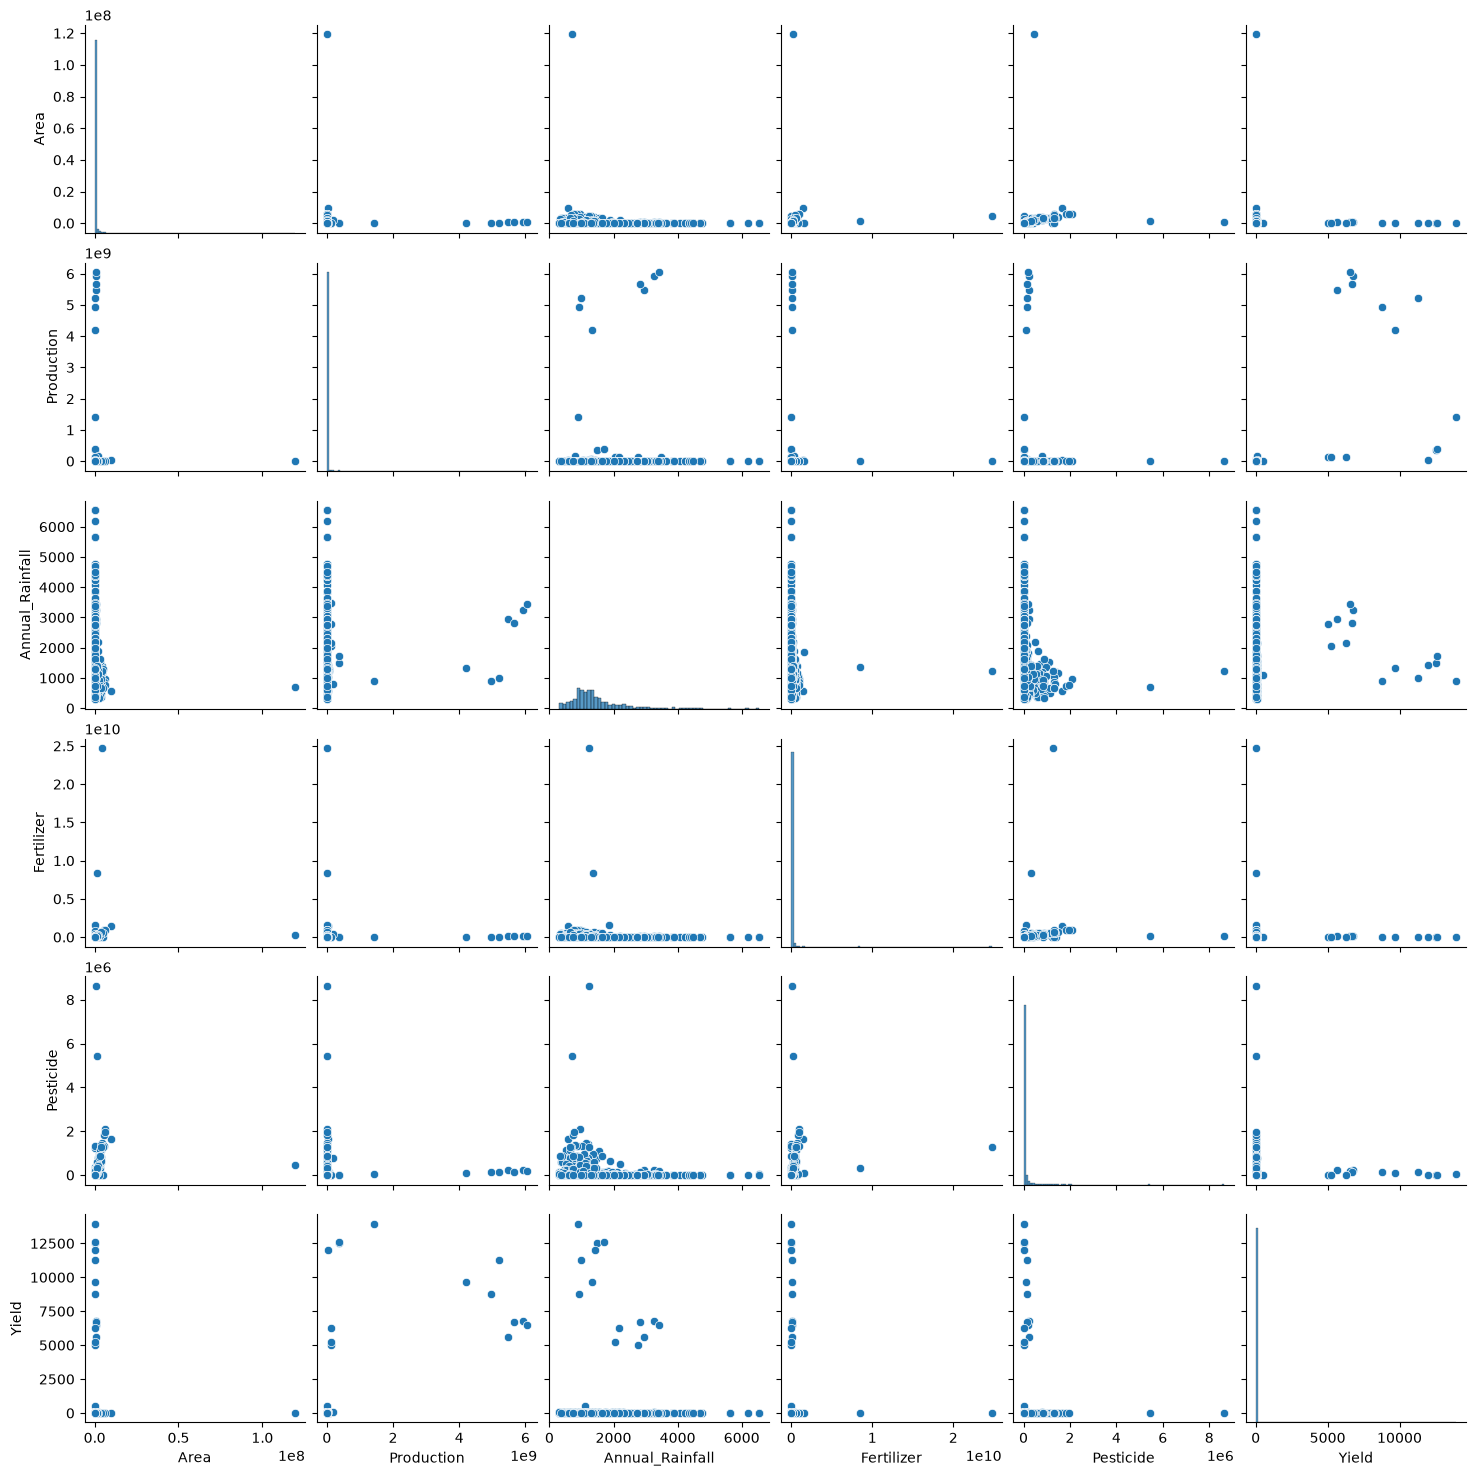

In [139]:
sns.pairplot(sample_df)

plt.show()